# MAE consolidado da base de ouro

**Etapa:** comparação principal dos quatro modelos

Os MAEs são recalculados diretamente das previsões congeladas e comparados nas mesmas 296 origens.

**Entrada:** predictions.csv, metrics.csv e baseline de persistência  
**Resultado principal:** Holt-Winters apresentou o menor MAE: 11,5331


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. MAE, ranking e baseline

In [3]:
protocol = load_protocol(require_data_decisions=True)
metrics = pd.read_csv(OUT / "metrics.csv")
predictions = pd.read_csv(OUT / "predictions.csv")
baseline = pd.read_csv(OUT / "baseline_persistencia.csv")

expected = {"SARIMAX", "Holt_Winters", "Random_Forest", "PLS_Regression"}
if set(metrics["model"]) != expected:
    raise RuntimeError(f"Faltam métricas: {expected - set(metrics['model'])}")

recalculated = (
    predictions.assign(abs_error=predictions["residual"].abs())
    .groupby("model", as_index=False)
    .agg(mae_recalculated=("abs_error", "mean"), n_recalculated=("abs_error", "size"))
)
metrics = metrics.drop(
    columns=["rank_gold", "mae_recalculated", "n_recalculated", "mae_difference"],
    errors="ignore",
).merge(
    recalculated,
    on="model",
    validate="one_to_one",
)
metrics["mae_difference"] = (metrics["mae"] - metrics["mae_recalculated"]).abs()
assert metrics["mae_difference"].max() < 1e-10
assert (metrics["n_forecasts"] == len(origins(protocol, "test"))).all()

metrics = metrics.sort_values("mae").reset_index(drop=True)
metrics["rank_gold"] = metrics.index + 1
metrics.to_csv(OUT / "metrics.csv", index=False)

baseline_mae = baseline["ABS_ERROR"].mean()
comparison = metrics[
    ["dataset", "model", "split", "n_forecasts", "mae", "rank_gold"]
].copy()
comparison["baseline_persistence_mae"] = baseline_mae
comparison["mae_difference_vs_persistence"] = comparison["mae"] - baseline_mae
comparison["improvement_pct_vs_persistence"] = (
    100 * (baseline_mae - comparison["mae"]) / baseline_mae
)
comparison.to_csv(OUT / "model_comparison_vs_baseline.csv", index=False)



,dataset,model,split,n_forecasts,mae,elapsed_seconds,mae_recalculated,n_recalculated,mae_difference,rank_gold
0,gold,Holt_Winters,test_final,296,11.533090,773.628423,11.533090,296,0.000000e+00,1
1,gold,SARIMAX,test_final,296,11.598841,3232.069655,11.598841,296,0.000000e+00,2
2,gold,PLS_Regression,test_final,296,11.600212,14.263879,11.600212,296,0.000000e+00,3
3,gold,Random_Forest,test_final,296,14.282618,1250.090067,14.282618,296,1.776357e-15,4


,reference,n_forecasts,mae,role
0,persistência,296,11.637669,diagnóstico; fora do ranking oficial


,dataset,model,split,n_forecasts,mae,rank_gold,baseline_persistence_mae,mae_difference_vs_persistence,improvement_pct_vs_persistence
0,gold,Holt_Winters,test_final,296,11.533090,1,11.637669,-0.104579,0.898622
1,gold,SARIMAX,test_final,296,11.598841,2,11.637669,-0.038828,0.333639
2,gold,PLS_Regression,test_final,296,11.600212,3,11.637669,-0.037457,0.321862
3,gold,Random_Forest,test_final,296,14.282618,4,11.637669,2.644949,-22.727478


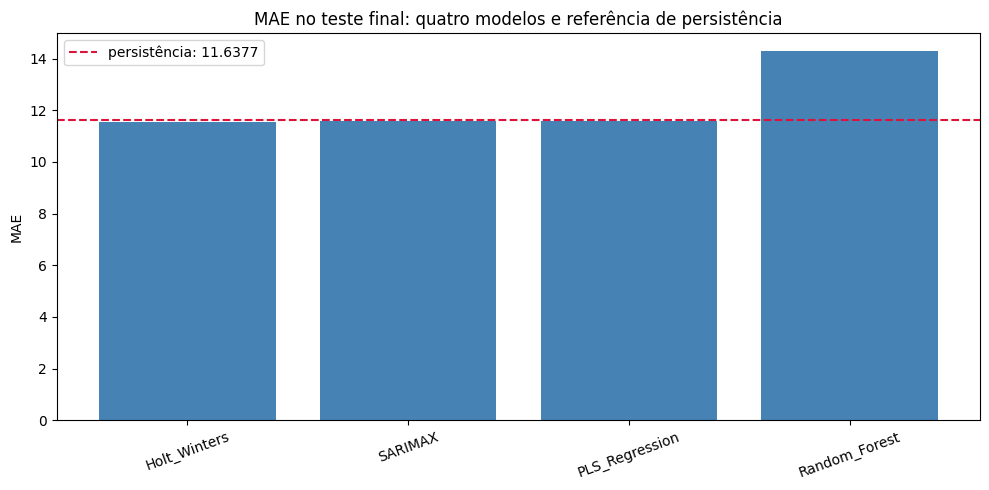

In [4]:
baseline_table = pd.DataFrame(
    [{
        "reference": "persistência",
        "n_forecasts": len(baseline),
        "mae": baseline_mae,
        "role": "diagnóstico; fora do ranking oficial",
    }]
)

display(metrics)
display(baseline_table)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison["model"], comparison["mae"], color="steelblue")
ax.axhline(
    baseline_mae,
    color="crimson",
    linestyle="--",
    label=f"persistência: {baseline_mae:.4f}",
)
ax.set_title("MAE no teste final: quatro modelos e referência de persistência")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "mae_comparison_gold.png", dpi=150, bbox_inches="tight")
plt.show()


## Interpretação

Holt-Winters ficou em primeiro. SARIMAX e PLS ficaram praticamente empatados, e os três superaram a persistência por margens pequenas.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/metrics.csv`
- `outputs/model_comparison_vs_baseline.csv`
- `outputs/mae_comparison_gold.png`